In [1]:
!pip install git+https://github.com/WildlifeDatasets/wildlife-datasets@develop
!pip install git+https://github.com/lightshing/wildlife-tools
!pip install pytorch-metric-learning
!pip install umap-learn
!pip install umap
!pip install record-keeper
!pip install faiss-cpu

  Cloning https://github.com/WildlifeDatasets/wildlife-datasets (to revision develop) to /tmp/pip-req-build-8hfmazm4
  Running command git clone --filter=blob:none --quiet https://github.com/WildlifeDatasets/wildlife-datasets /tmp/pip-req-build-8hfmazm4
  Running command git checkout -b develop --track origin/develop
  Switched to a new branch 'develop'
  Branch 'develop' set up to track remote branch 'develop' from 'origin'.
  Resolved https://github.com/WildlifeDatasets/wildlife-datasets to commit 753d9bf64861c3e17011136b3436bf58bf02317f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 7.8 MB/s eta 0:00:00
  Created wheel for wildlife-datasets: filename=wildlife_datasets-1.0.6-py3-none-any.whl size=88077 sha256=8a088fcd891e9e5562065e81206ccf72cb673beca44067a07d1f8c04dd6359ae
  Stored in directory: /tmp/pip-ephem-wheel-cache-x9zc95io/wheels/a

In [2]:
import os
import numpy as np
import pandas as pd
import timm
import torchvision.transforms as T
import torch
from torch import nn
from torch import optim
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from wildlife_datasets.datasets import AnimalCLEF2025
from wildlife_datasets import splits
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
import logging



from pytorch_metric_learning import distances, reducers

import pytorch_metric_learning
from pytorch_metric_learning import losses, miners, samplers
from pytorch_metric_learning.utils.accuracy_calculator import AccuracyCalculator
import pytorch_metric_learning.utils.logging_presets as LP
from pytorch_metric_learning.trainers import TrainWithClassifier
from pytorch_metric_learning.testers import BaseTester
import torch
import os
from wildlife_tools.features import DeepFeatures
from wildlife_tools.similarity import CosineSimilarity


logging.getLogger().setLevel(logging.INFO)
logging.info("VERSION %s" % pytorch_metric_learning.__version__)

2025-05-03 08:52:21.701612: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746262341.940241      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746262342.003740      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
import numpy as np
from typing import List, Union
import os
import numpy as np
import pandas as pd
import timm
import torchvision.transforms as T
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
from wildlife_datasets.datasets import AnimalCLEF2025
from wildlife_tools.features import DeepFeatures
from wildlife_tools.similarity import CosineSimilarity

def baks_compute(
        y_true: Union[List, np.ndarray],
        y_pred: Union[List, np.ndarray],
        identity_test_only: Union[List, np.ndarray]
    ) -> float:
    """Computes BAKS (balanced accuracy on known samples).
    
    Focuses only on samples with known identities (not in identity_test_only).
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        identity_test_only: Labels of unknown identities (only in test set)
        
    Returns:
        Balanced accuracy score for known samples
    """
    # Convert inputs to numpy arrays with object dtype to handle mixed types
    y_true = np.array(y_true, dtype=object)
    y_pred = np.array(y_pred, dtype=object)
    identity_test_only = np.array(identity_test_only, dtype=object)
    
    # Filter out unknown samples
    mask = ~np.isin(y_true, identity_test_only)
    y_true_known = y_true[mask]
    y_pred_known = y_pred[mask]
    
    if len(y_true_known) == 0:
        return 0.0
    
    # Get unique classes in the filtered true labels
    unique_classes = np.unique(y_true_known)
    n_classes = len(unique_classes)
    
    # Compute per-class accuracy and average
    class_accuracies = []
    for cls in unique_classes:
        cls_mask = (y_true_known == cls)
        if np.sum(cls_mask) > 0:
            cls_acc = np.mean(y_pred_known[cls_mask] == cls)
            class_accuracies.append(cls_acc)
    
    # Return the balanced accuracy (mean of per-class accuracies)
    return np.mean(class_accuracies) if class_accuracies else 0.0

def baus_compute(
        y_true: Union[List, np.ndarray],
        y_pred: Union[List, np.ndarray],
        identity_test_only: Union[List, np.ndarray],
        new_class: Union[int, str]
    ) -> float:
    """Computes BAUS (balanced accuracy on unknown samples).
    
    Focuses only on samples with unknown identities (in identity_test_only).
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        identity_test_only: Labels of unknown identities (only in test set)
        new_class: Label used for identifying unknown samples
        
    Returns:
        Balanced accuracy score for unknown samples
    """
    # Convert inputs to numpy arrays with object dtype to handle mixed types
    y_true = np.array(y_true, dtype=object)
    y_pred = np.array(y_pred, dtype=object)
    identity_test_only = np.array(identity_test_only, dtype=object)
    
    # Filter to include only unknown samples
    mask = np.isin(y_true, identity_test_only)
    y_true_unknown = y_true[mask]
    y_pred_unknown = y_pred[mask]
    
    if len(y_true_unknown) == 0:
        return 0.0
    
    # Get unique unknown classes
    unique_unknown_classes = np.unique(y_true_unknown)
    
    # For each unknown class, check if they were correctly predicted as new_class
    class_accuracies = []
    for cls in unique_unknown_classes:
        cls_mask = (y_true_unknown == cls)
        if np.sum(cls_mask) > 0:
            # For unknown samples, correct prediction is new_class
            cls_acc = np.mean(y_pred_unknown[cls_mask] == new_class)
            class_accuracies.append(cls_acc)
    
    # Return the balanced accuracy (mean of per-class accuracies)
    return np.mean(class_accuracies) if class_accuracies else 0.0


def compute_geometric_mean(baks, baus):
    return np.sqrt(baks * baus)


def create_sample_submission(dataset_query, predictions, file_name='sample_submission.csv'):
    df = pd.DataFrame({
        'image_id': dataset_query.metadata['image_id'],
        'identity': predictions
    })
    df.to_csv(file_name, index=False)
    
root = '/kaggle/input/animal-clef-2025'
import cv2
import numpy as np
from PIL import Image
class GammaCorrection(object):
    """
    Gamma校正增强的Transform实现
    """
    def __init__(self, gamma=1.0):
        self.gamma = gamma
        self.inv_gamma = 1.0 / gamma
        self.table = np.array([((i / 255.0) ** self.inv_gamma) * 255
                             for i in np.arange(0, 256)]).astype("uint8")
    
    def __call__(self, img):
        # 将PIL图像转换为numpy数组
        img_np = np.array(img)
        # 应用gamma校正
        img_corrected = cv2.LUT(img_np, self.table)
        # 转回PIL图像
        return Image.fromarray(img_corrected)

# 修改transform
transform = T.Compose([
    T.Resize([384, 384]),
    #CLAHE(clip_limit=2.0, tile_grid_size=(8,8)),  # 添加CLAHE
    GammaCorrection(gamma=0.5),  # 添加Gamma校正
    #ImgAugTransform(),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# 对于display transform，我们也可以添加这些增强
transform_display = T.Compose([
    T.Resize([384, 384]),
    #CLAHE(clip_limit=2.0, tile_grid_size=(8,8)),
    GammaCorrection(gamma=0.5),
    #ImgAugTransform()
])



In [4]:
root = '/kaggle/input/offline-imgaug/aug'
out_root = '/kaggle/working'
checkpoint_out_path = '/kaggle/working/model_checkpoints'

In [5]:
set_split_seed = 333
training_seed = 666
batch_size = 64
Vmargin = 0.2

In [6]:
name = 'hf-hub:BVRA/MegaDescriptor-L-384'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mega = timm.create_model(name, num_classes=0, pretrained=True)
print(device)
mega = mega.to(device)

config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

cuda


In [7]:
transform_mega_ori = timm.data.create_transform(
    **timm.data.resolve_data_config(mega.pretrained_cfg)
)
transform_mega_ori

Compose(
    Resize(size=426, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(384, 384))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)

In [8]:
transform = T.Compose([
    T.ToTensor(),
    *transform_mega_ori.transforms
    ])

### 模型预处理

In [9]:
print(mega)

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=192, out_features=576, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=192, out_features=192, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=192, out_features=768, bias=True)
            (act): GELU(approximate='none')
            (

In [10]:
mega.head.drop = nn.Dropout(p=0.33)
mega.head.fc = nn.Linear(1536, 512)

In [11]:
mega.load_state_dict(torch.load("/kaggle/input/new-m-notebook0f84e68280/metric_learning_models/trunk_best19.pth"))

/tmp/ipykernel_31/1826463808.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mega.load_state_dict(torch.load("/kaggle/input/new-m-notebook0f84e68280/metric_learning_mode

<All keys matched successfully>

### 测试输出

In [12]:
mega.to(device)
test_input = torch.ones(4, 3, 384, 384)
test_input = test_input.to(device)
with torch.no_grad():
    test_output = mega(test_input)
print(test_output.shape)

torch.Size([4, 512])


In [13]:
from sklearn.preprocessing import LabelEncoder
root = '/kaggle/input/offline-imgaug/aug'
# Loading the dataset
dataset = AnimalCLEF2025(root, transform=transform, load_label=True)
# data fillna
dataset.metadata.loc[dataset.metadata['species'].isna(), 'species'] = 'salamander'
dataset_database = dataset.get_subset(dataset.metadata['split'] == 'database')
dataset_query = dataset.get_subset(dataset.metadata['split'] == 'query')
n_query = len(dataset_query)

In [14]:
# transform label
df_database = dataset_database.df
df_database['name'] = df_database['identity'].copy()
encoder = LabelEncoder()
df_database['identity'] = encoder.fit_transform(df_database['identity'])
dataset_database.df = df_database

In [15]:
# split
# availableSet & testSet
from wildlife_datasets import splits
openSplitter = splits.OpenSetSplit(0.9, 0.1, seed=333)
for idx_train, idx_test in openSplitter.split(df_database):
    splits.analyze_split(df_database, idx_train, idx_test)
df_train, df_test = df_database.loc[idx_train], df_database.loc[idx_test]
availableSet = dataset_database.get_subset(df_train.index)
testSet = dataset_database.get_subset(df_test.index)
df_availableSet = availableSet.df

# trainSet & thresholdSet
openSplitter = splits.OpenSetSplit(0.9, 0.1, seed=333)
for idx_train, idx_test in openSplitter.split(df_availableSet):
    splits.analyze_split(df_availableSet, idx_train, idx_test)
df_train, df_test = df_availableSet.loc[idx_train], df_availableSet.loc[idx_test]
trainSet = availableSet.get_subset(df_train.index)
thresholdSet = availableSet.get_subset(df_test.index)
df_database_training = trainSet.df

# training & test 
closeSplitter = splits.ClosedSetSplit(0.9, seed=333)
for idx_train, idx_test in closeSplitter.split(df_database_training):
    splits.analyze_split(df_database_training, idx_train, idx_test)
df_training, df_val = df_database_training.loc[idx_train], df_database_training.loc[idx_test]
training = trainSet.get_subset(df_training.index)
test = trainSet.get_subset(df_val.index)

Split: time-unaware open-set
Samples: train/test/unassigned/total = 12399/2492/0/14891
Classes: train/test/unassigned/total = 1002/1102/0/1102
Samples: train only/test only        = 0/1490
Classes: train only/test only/joint  = 0/100/1002

Fraction of train set     = 83.27%
Fraction of test set only = 10.01%
Split: time-unaware open-set
Samples: train/test/unassigned/total = 10244/2155/0/12399
Classes: train/test/unassigned/total = 912/1002/0/1002
Samples: train only/test only        = 0/1243
Classes: train only/test only/joint  = 0/90/912

Fraction of train set     = 82.62%
Fraction of test set only = 10.03%
Split: time-unaware closed-set
Samples: train/test/unassigned/total = 8802/1442/0/10244
Classes: train/test/unassigned/total = 912/912/0/912
Samples: train only/test only        = 0/0
Classes: train only/test only/joint  = 0/0/912

Fraction of train set     = 85.92%
Fraction of test set only = 0.00%


In [33]:
# df_ofTest = test.df
# closeSplitter = splits.ClosedSetSplit(0.1, seed=333)
# for idx_train, idx_test in closeSplitter.split(df_ofTest):
#     splits.analyze_split(df_ofTest, idx_train, idx_test)
# df_training, df_val = df_ofTest.loc[idx_train], df_ofTest.loc[idx_test]
# ccc = test.get_subset(df_val.index)

Split: time-unaware closed-set
Samples: train/test/unassigned/total = 920/522/0/1442
Classes: train/test/unassigned/total = 912/172/0/912
Samples: train only/test only        = 740/0
Classes: train only/test only/joint  = 740/0/172

Fraction of train set     = 63.80%
Fraction of test set only = 0.00%


In [44]:
df_ofTrain = training.df
closeSplitter = splits.ClosedSetSplit(0.001, seed=333)
for idx_train, idx_test in closeSplitter.split(df_ofTrain):
    splits.analyze_split(df_ofTrain, idx_train, idx_test)
df_training, df_val = df_ofTrain.loc[idx_train], df_ofTrain.loc[idx_test]
ccc = training.get_subset(df_training.index)

Split: time-unaware closed-set
Samples: train/test/unassigned/total = 912/7890/0/8802
Classes: train/test/unassigned/total = 912/912/0/912
Samples: train only/test only        = 0/0
Classes: train only/test only/joint  = 0/0/912

Fraction of train set     = 10.36%
Fraction of test set only = 0.00%


In [45]:
len(ccc)

912

In [16]:
testSet.df.dataset.value_counts()

dataset
SeaTurtleID2022     1204
SalamanderID2025     815
LynxID2025           473
Name: count, dtype: int64

In [17]:
# check
def analyze_new_individuals(test_df, available_df):
    """分析测试集中每个物种的新个体（不在可用集中的个体）及其图片数量"""
    # 获取可用集中的所有个体ID
    available_individuals = set(available_df['identity'].unique())
    
    # 在测试集中标记哪些个体是新的（不在可用集中）
    test_df['is_new_individual'] = ~test_df['identity'].isin(available_individuals)
    
    # 按物种分组统计新个体的图片数量
    analysis = test_df[test_df['is_new_individual']].groupby('species').agg(
        new_individuals=('identity', 'nunique'),
        new_images=('image_id', 'count')
    ).reset_index()
    
    return analysis

# 运行分析
new_species_analysis = analyze_new_individuals(testSet.df, availableSet.df)

# 打印结果
print("各物种的新个体和图片统计:")
print(new_species_analysis.to_string(index=False))

各物种的新个体和图片统计:
          species  new_individuals  new_images
loggerhead turtle               37         803
             lynx                7         403
       salamander               56         284


In [18]:
# to DataLoader
class AnimalReIDDataset(Dataset):
    def __init__(self, dataloader, transform=None):
        self.dataloader = dataloader
        self.transform = transform
        self.identity_to_idx = {id_: idx for idx, id_ in enumerate(dataloader.metadata['identity'].unique())} # one identity got one index as its label
        
    def __len__(self):
        return len(self.dataloader)
    
    def __getitem__(self, idx):
        img, _ = self.dataloader[idx]
        identity = self.dataloader.metadata.iloc[idx]['identity']
        label = self.identity_to_idx[identity]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

# 2. 创建数据加载器
batch_size = 32
train_dataset = AnimalReIDDataset(training,transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataset_1 = AnimalReIDDataset(test,transform)
val_dataloader_1 = DataLoader(val_dataset_1, batch_size=batch_size, shuffle=True, num_workers=2)

# 打印训练集中的个体数量
num_classes = len(training.metadata['identity'].unique())
print(f"训练集中共有{num_classes}个不同的个体")

训练集中共有912个不同的个体


In [19]:
extractor = DeepFeatures(mega, device=device, batch_size=64, num_workers=0)
features_database = extractor(training)
features_query = extractor(thresholdSet)

100%|███████████████████████████████████████████████████████████████| 34/34 [02:45<00:00,  4.88s/it]


In [20]:
similarity = CosineSimilarity()(features_query, features_database)

In [46]:
from wildlife_tools.similarity import CosineSimilarity
from wildlife_tools.similarity.wildfusion import SimilarityPipeline, WildFusion
from wildlife_tools.similarity.pairwise.lightglue import MatchLightGlue
from wildlife_tools.features.local import AlikedExtractor
from wildlife_tools.similarity.calibration import IsotonicCalibration
device = 'cuda'
transforms_aliked = T.Compose([
    T.Resize([512, 512]),
    GammaCorrection(gamma=0.5),
    T.ToTensor()
])
matcher_aliked = SimilarityPipeline(
    matcher = MatchLightGlue(features='aliked', device=device, batch_size=16),
    extractor = AlikedExtractor(),
    transform = transforms_aliked,
    calibration = IsotonicCalibration()
)

matcher_mega = SimilarityPipeline(
    matcher = CosineSimilarity(),
    extractor = DeepFeatures(model=mega, device=device, batch_size=16),
    transform = transform,
    calibration = IsotonicCalibration()
)

dataset_calibration = ccc

wildfusion_submission = WildFusion(calibrated_pipelines = [matcher_aliked, matcher_mega], priority_pipeline = matcher_mega)
wildfusion_submission.fit_calibration(dataset_calibration, dataset_calibration)

similarity = wildfusion_submission(thresholdSet, training, B=20)

100%|█████████████████████████████████████████████████████████████| 551/551 [07:27<00:00,  1.23it/s]


In [47]:
import pickle

# 定义要保存的变量（确保这些变量已正确生成）
save_data = {
    "similarity": similarity  # for thredsholdSet similarity
    #"wildfusion_submission": wildfusion_submission
}

# 保存到 Kaggle 工作目录
with open("/kaggle/working/saved_variablesALIKED222.pkl", "wb") as f:
    pickle.dump(save_data, f)

print("变量已保存到 /kaggle/working/saved_variables2ALIKED222.pkl")

变量已保存到 /kaggle/working/saved_variables2ALIKED222.pkl


In [48]:
similarity.shape

(2155, 8802)

In [49]:
n_query = len(thresholdSet)
pred_idx_threshold = similarity.argsort(axis=1)[:,-1]
pred_scores_threshold = similarity[range(n_query), pred_idx_threshold]

In [50]:
pred_scores_threshold.shape

(2155,)

In [51]:
# Get species indices
lynx_indices = thresholdSet.df[thresholdSet.df['species'] == 'lynx'].index
loggerhead_indices = thresholdSet.df[thresholdSet.df['species'] == 'loggerhead turtle'].index
salamander_indices = thresholdSet.df[thresholdSet.df['species'] == 'salamander'].index

# Get prediction indices
pred_idx_threshold_lynx = pred_idx_threshold[lynx_indices]
pred_idx_threshold_loggerhead = pred_idx_threshold[loggerhead_indices]
pred_idx_threshold_salamander = pred_idx_threshold[salamander_indices]

# Get prediction scores
pred_scores_threshold_lynx = pred_scores_threshold[lynx_indices]
pred_scores_threshold_loggerhead = pred_scores_threshold[loggerhead_indices]
pred_scores_threshold_salamander = pred_scores_threshold[salamander_indices]

In [52]:
unseen_ids_threshold = []
all_ids = df_database['identity'].unique()

for i in all_ids:
    if i in thresholdSet.metadata['identity'].tolist():
        if i not in training.metadata['identity'].tolist():
            # if not in the training set, the id in test set havent been seen before
            unseen_ids_threshold.append(i)

In [55]:
thresholdSet_true_labels = thresholdSet.labels_string.astype(str)
unseen_ids_threshold = pd.Series(unseen_ids_threshold).astype(str)
thresholds = np.arange(0, 1, 0.01)
results = []
labels = np.array(training.labels_string)


for threshold in thresholds:
    predictions = labels[pred_idx_threshold].copy()
    #print(predictions[1])
    predictions[pred_scores_threshold < threshold] = 'new_individual'

    baks = baks_compute(thresholdSet_true_labels, predictions, unseen_ids_threshold)
    baus = baus_compute(thresholdSet_true_labels, predictions, unseen_ids_threshold, 'new_individual')
    geo_mean = compute_geometric_mean(baks, baus)
    results.append((threshold, baks, baus, geo_mean))

    print(f"Threshold: {threshold:.2f} | BAKS: {baks:.4f} | BAUS: {baus:.4f} | GEO_MEAN: {geo_mean:.4f}")
    
# comment: increase the threshold can lead to the increase of baus and decrease of baks

Threshold: 0.00 | BAKS: 0.6118 | BAUS: 0.0000 | GEO_MEAN: 0.0000
Threshold: 0.01 | BAKS: 0.6118 | BAUS: 0.0000 | GEO_MEAN: 0.0000
Threshold: 0.02 | BAKS: 0.6118 | BAUS: 0.0000 | GEO_MEAN: 0.0000
Threshold: 0.03 | BAKS: 0.6118 | BAUS: 0.0044 | GEO_MEAN: 0.0517
Threshold: 0.04 | BAKS: 0.6118 | BAUS: 0.0099 | GEO_MEAN: 0.0779
Threshold: 0.05 | BAKS: 0.6107 | BAUS: 0.0355 | GEO_MEAN: 0.1473
Threshold: 0.06 | BAKS: 0.6107 | BAUS: 0.0825 | GEO_MEAN: 0.2245
Threshold: 0.07 | BAKS: 0.6107 | BAUS: 0.1383 | GEO_MEAN: 0.2906
Threshold: 0.08 | BAKS: 0.6096 | BAUS: 0.2341 | GEO_MEAN: 0.3778
Threshold: 0.09 | BAKS: 0.6064 | BAUS: 0.3424 | GEO_MEAN: 0.4557
Threshold: 0.10 | BAKS: 0.6053 | BAUS: 0.4231 | GEO_MEAN: 0.5060
Threshold: 0.11 | BAKS: 0.5987 | BAUS: 0.4812 | GEO_MEAN: 0.5367
Threshold: 0.12 | BAKS: 0.5932 | BAUS: 0.5647 | GEO_MEAN: 0.5788
Threshold: 0.13 | BAKS: 0.5888 | BAUS: 0.6302 | GEO_MEAN: 0.6092
Threshold: 0.14 | BAKS: 0.5735 | BAUS: 0.6907 | GEO_MEAN: 0.6293
Threshold: 0.15 | BAKS: 0

Evaluating Lynx:
Threshold: 0.00 | BAKS: 0.4545 | BAUS: 0.0000 | GEO_MEAN: 0.0000
Threshold: 0.01 | BAKS: 0.4545 | BAUS: 0.0000 | GEO_MEAN: 0.0000
Threshold: 0.02 | BAKS: 0.4545 | BAUS: 0.0000 | GEO_MEAN: 0.0000
Threshold: 0.03 | BAKS: 0.4545 | BAUS: 0.0000 | GEO_MEAN: 0.0000
Threshold: 0.04 | BAKS: 0.4545 | BAUS: 0.0000 | GEO_MEAN: 0.0000
Threshold: 0.05 | BAKS: 0.4545 | BAUS: 0.0000 | GEO_MEAN: 0.0000
Threshold: 0.06 | BAKS: 0.4545 | BAUS: 0.0030 | GEO_MEAN: 0.0372
Threshold: 0.07 | BAKS: 0.4545 | BAUS: 0.0030 | GEO_MEAN: 0.0372
Threshold: 0.08 | BAKS: 0.4545 | BAUS: 0.0030 | GEO_MEAN: 0.0372
Threshold: 0.09 | BAKS: 0.4545 | BAUS: 0.0030 | GEO_MEAN: 0.0372
Threshold: 0.10 | BAKS: 0.4545 | BAUS: 0.0030 | GEO_MEAN: 0.0372
Threshold: 0.11 | BAKS: 0.4545 | BAUS: 0.0030 | GEO_MEAN: 0.0372
Threshold: 0.12 | BAKS: 0.4545 | BAUS: 0.0130 | GEO_MEAN: 0.0770
Threshold: 0.13 | BAKS: 0.4545 | BAUS: 0.0130 | GEO_MEAN: 0.0770
Threshold: 0.14 | BAKS: 0.4394 | BAUS: 0.0130 | GEO_MEAN: 0.0757
Threshol

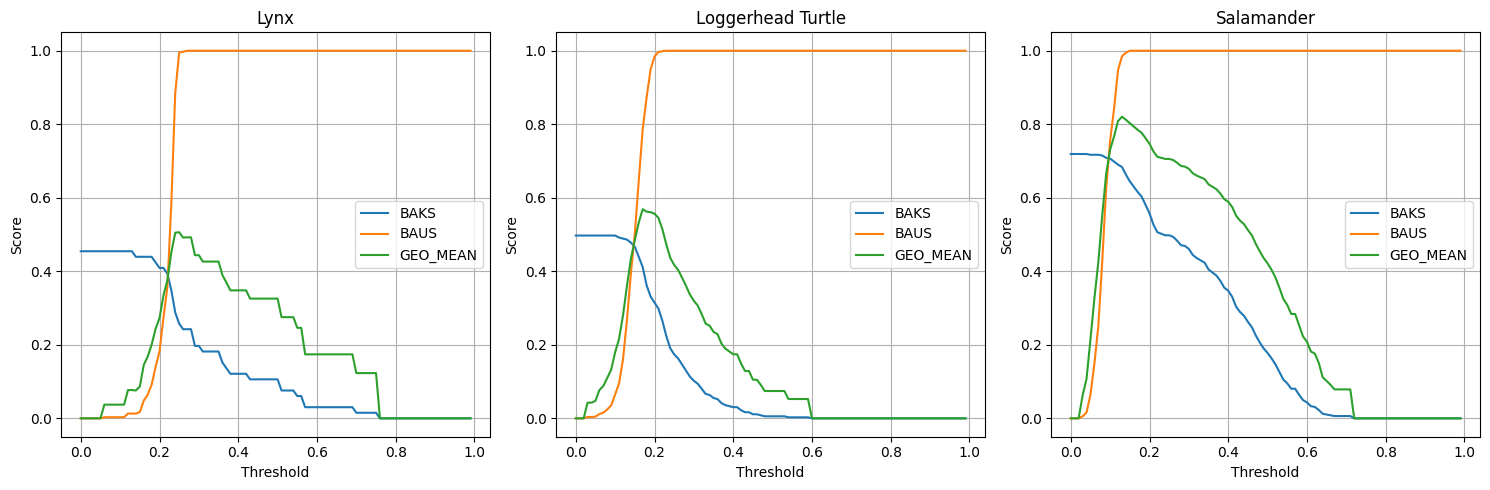

In [56]:
# First get the filtered labels for each species
thresholdSet_true_labels_lynx = thresholdSet_true_labels[lynx_indices]
thresholdSet_true_labels_loggerhead = thresholdSet_true_labels[loggerhead_indices]
thresholdSet_true_labels_salamander = thresholdSet_true_labels[salamander_indices]

# Filter unseen_ids for each species
unseen_ids_threshold_lynx =  [str(x) for x in unseen_ids_threshold]
unseen_ids_threshold_loggerhead =  [str(x) for x in unseen_ids_threshold]
unseen_ids_threshold_salamander =  [str(x) for x in unseen_ids_threshold]

# Version for Lynx
def evaluate_lynx_thresholds():
    thresholds = np.arange(0, 1, 0.01)
    results_lynx = []
    labels = np.array(training.labels_string)

    print("Evaluating Lynx:")
    for threshold in thresholds:
        predictions = labels[pred_idx_threshold_lynx].copy()
        predictions[pred_scores_threshold_lynx < threshold] = 'new_individual'

        baks = baks_compute(thresholdSet_true_labels_lynx, predictions, unseen_ids_threshold_lynx)
        baus = baus_compute(thresholdSet_true_labels_lynx, predictions, unseen_ids_threshold_lynx, 'new_individual')
        geo_mean = compute_geometric_mean(baks, baus)
        results_lynx.append((threshold, baks, baus, geo_mean))

        print(f"Threshold: {threshold:.2f} | BAKS: {baks:.4f} | BAUS: {baus:.4f} | GEO_MEAN: {geo_mean:.4f}")
    return results_lynx

# Version for Loggerhead Turtle
def evaluate_loggerhead_thresholds():
    thresholds = np.arange(0, 1, 0.01)
    results_loggerhead = []
    labels = np.array(training.labels_string)

    print("\nEvaluating Loggerhead Turtle:")
    for threshold in thresholds:
        predictions = labels[pred_idx_threshold_loggerhead].copy()
        predictions[pred_scores_threshold_loggerhead < threshold] = 'new_individual'

        baks = baks_compute(thresholdSet_true_labels_loggerhead, predictions, unseen_ids_threshold_loggerhead)
        baus = baus_compute(thresholdSet_true_labels_loggerhead, predictions, unseen_ids_threshold_loggerhead, 'new_individual')
        geo_mean = compute_geometric_mean(baks, baus)
        results_loggerhead.append((threshold, baks, baus, geo_mean))

        print(f"Threshold: {threshold:.2f} | BAKS: {baks:.4f} | BAUS: {baus:.4f} | GEO_MEAN: {geo_mean:.4f}")
    return results_loggerhead

# Version for Salamander
def evaluate_salamander_thresholds():
    thresholds = np.arange(0, 1, 0.01)
    results_salamander = []
    labels = np.array(training.labels_string)

    print("\nEvaluating Salamander:")
    for threshold in thresholds:
        predictions = labels[pred_idx_threshold_salamander].copy()
        predictions[pred_scores_threshold_salamander < threshold] = 'new_individual'

        baks = baks_compute(thresholdSet_true_labels_salamander, predictions, unseen_ids_threshold_salamander)
        baus = baus_compute(thresholdSet_true_labels_salamander, predictions, unseen_ids_threshold_salamander, 'new_individual')
        geo_mean = compute_geometric_mean(baks, baus)
        results_salamander.append((threshold, baks, baus, geo_mean))

        print(f"Threshold: {threshold:.2f} | BAKS: {baks:.4f} | BAUS: {baus:.4f} | GEO_MEAN: {geo_mean:.4f}")
    return results_salamander

# Run evaluations
results_lynx = evaluate_lynx_thresholds()
results_loggerhead = evaluate_loggerhead_thresholds()
results_salamander = evaluate_salamander_thresholds()

# Optional: Plot results for comparison
def plot_results(results_lynx, results_loggerhead, results_salamander):
    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    for results, ax, title in zip([results_lynx, results_loggerhead, results_salamander], 
                                [ax1, ax2, ax3],
                                ['Lynx', 'Loggerhead Turtle', 'Salamander']):
        thresholds = [r[0] for r in results]
        baks = [r[1] for r in results]
        baus = [r[2] for r in results]
        geo_mean = [r[3] for r in results]
        
        ax.plot(thresholds, baks, label='BAKS')
        ax.plot(thresholds, baus, label='BAUS')
        ax.plot(thresholds, geo_mean, label='GEO_MEAN')
        ax.set_title(title)
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Score')
        ax.legend()
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()

# Plot the results
plot_results(results_lynx, results_loggerhead, results_salamander)